In [1]:
import numpy as np
import xarray as xr
import time
import os
import glob
from typing import Tuple, List, Dict, Optional
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy import signal, fft
import cmaps
import sys
from pathlib import Path
import psutil
import dask
import gc
WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
from wave_tools import calculate_cross_spectrum,remove_annual_cycle
from wave_tools.utils import  get_curve

# ============ 内存监控工具 ============
class MemoryMonitor:
    """内存监控类"""
    def __init__(self):
        self.process = psutil.Process()
        
    def get_memory_info(self):
        """获取当前内存使用信息"""
        mem = self.process.memory_info()
        mem_percent = self.process.memory_percent()
        virtual_mem = psutil.virtual_memory()
        
        return {
            'rss_gb': mem.rss / 1024**3,  # 物理内存 (GB)
            'vms_gb': mem.vms / 1024**3,  # 虚拟内存 (GB)
            'percent': mem_percent,        # 进程内存占用百分比
            'available_gb': virtual_mem.available / 1024**3,  # 系统可用内存 (GB)
            'total_gb': virtual_mem.total / 1024**3           # 系统总内存 (GB)
        }
    
    def print_memory_status(self, label=""):
        """打印内存状态"""
        info = self.get_memory_info()
        print(f"\n{'='*60}")
        print(f"💾 内存状态 {f'- {label}' if label else ''}")
        print(f"{'='*60}")
        print(f"  进程物理内存使用: {info['rss_gb']:.2f} GB")
        print(f"  进程虚拟内存使用: {info['vms_gb']:.2f} GB")
        print(f"  进程内存占比: {info['percent']:.1f}%")
        print(f"  系统可用内存: {info['available_gb']:.2f} GB / {info['total_gb']:.2f} GB")
        print(f"{'='*60}\n")
        
        # 如果可用内存不足10GB，发出警告
        if info['available_gb'] < 10:
            print("⚠️  警告: 系统可用内存不足10GB!")
        
        return info

# 创建全局内存监控器
mem_monitor = MemoryMonitor()

FIG_SAVE_DIR = "../figures/pr&lhf_cross_spectrum/"

# 创建必要的目录
for d in [FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)

EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

mem_monitor.print_memory_status("初始化")



💾 内存状态 - 初始化
  进程物理内存使用: 1.20 GB
  进程虚拟内存使用: 19.45 GB
  进程内存占比: 0.2%
  系统可用内存: 267.70 GB / 501.87 GB



{'rss_gb': 1.2008705139160156,
 'vms_gb': 19.447227478027344,
 'percent': 0.23927829153531865,
 'available_gb': 267.69879150390625,
 'total_gb': 501.8719024658203}

In [2]:
# ============ 加载降水数据 ============

def load_precipitation_data(experiment='cntl', data_dir='/work/mh1498/m301257/data_origin', 
                           chunks={'time': 5000}):
    """
    加载降水数据 (使用 chunking 避免内存溢出)
    
    Parameters:
    -----------
    experiment : str
        实验名称，可选: 'cntl', 'p4k', '4co2'
    data_dir : str
        数据目录
    chunks : dict
        数据分块参数，默认按时间维度每100个时间步分一块
    
    Returns:
    --------
    xr.DataArray
        降水数据 (lazy loading)
    """
    # 构建文件路径
    file_path = os.path.join(data_dir, f'pr_{experiment}_2deg_interp.nc')
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"未找到实验 {experiment} 的降水数据文件: {file_path}")
    
    print(f"📂 加载数据: {file_path}")
    
    # 使用 chunks 参数实现 lazy loading
    try:
        pr = xr.open_dataarray(file_path, engine='netcdf4', chunks=chunks)
    except:
        try:
            pr = xr.open_dataarray(file_path, engine='h5netcdf', chunks=chunks)
        except:
            pr = xr.open_dataarray(file_path, chunks=chunks)
    
    print(f"✅ 数据加载成功 (lazy loading)")
    print(f"   形状: {pr.shape}")
    print(f"   维度: {pr.dims}")
    print(f"   数据块: {pr.chunks}")
    if hasattr(pr, 'time'):
        print(f"   时间范围: {pr.time.values[0]} to {pr.time.values[-1]}")
    
    # 估算数据大小
    data_size_gb = pr.nbytes / 1024**3
    print(f"   估算数据大小: {data_size_gb:.2f} GB")
    
    return pr


def load_all_precipitation_data(chunks={'time': 5000}):
    """
    加载所有实验的降水数据 (使用 lazy loading)
    
    Parameters:
    -----------
    chunks : dict
        数据分块参数
    
    Returns:
    --------
    dict
        包含所有实验降水数据的字典
    """
    print("\n" + "="*60)
    print("加载所有降水数据")
    print("="*60)
    
    mem_monitor.print_memory_status("加载降水数据前")
    
    experiments = ['cntl', 'p4k', '4co2']
    pr_data = {}
    
    for exp in experiments:
        try:
            print(f"\n加载 {exp.upper()}...")
            pr = load_precipitation_data(exp, chunks=chunks)
            pr_data[exp] = pr
        except Exception as e:
            print(f"❌ 错误: {e}")
    
    print(f"\n{'='*60}")
    print(f"✅ 成功加载 {len(pr_data)} 个实验的数据")
    print(f"{'='*60}")
    
    mem_monitor.print_memory_status("加载降水数据后")
    
    return pr_data


In [3]:
def _ocean():
    fraction = xr.open_dataarray(r'../processed_data/land_mask_2deg.nc')
    return fraction == 0
ocean_mask = _ocean()

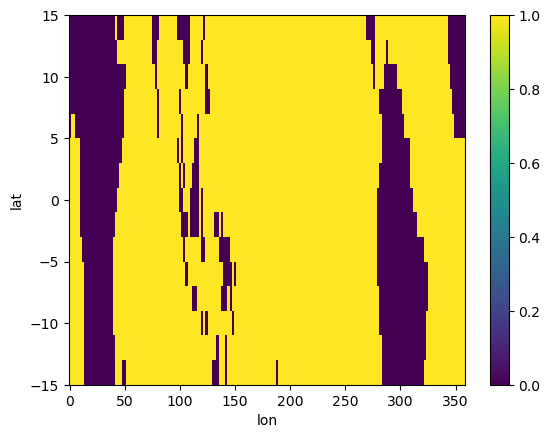

In [4]:
ocean_mask.plot()


In [5]:
def get_latent_heat_flux():
    """加载潜热通量数据"""
    lhf_data = {}
    lhf_cntl = xr.open_dataarray(r'/work/mh1498/m301257/processed_data/2d_layers/hfls_cntl/hfls_2deg_interp.nc', chunks={'time': 5000})*(-1)
    lhf_p4k = xr.open_dataarray(r'/work/mh1498/m301257/processed_data/2d_layers/hfls_p4k/hfls_2deg_interp.nc', chunks={'time': 5000})*(-1)
    lhf_4co2 = xr.open_dataarray(r'/work/mh1498/m301257/processed_data/2d_layers/hfls_4co2/hfls_2deg_interp.nc', chunks={'time': 5000})*(-1)
    lhf_data['cntl'] = lhf_cntl
    lhf_data['p4k'] = lhf_p4k
    lhf_data['4co2'] = lhf_4co2
    return lhf_data
def get_olr():
    """加载OLR数据"""
    olr_data = {}
    olr_cntl = xr.open_dataarray(r'/work/mh1498/m301257/processed_data/2d_layers/rlut_cntl/rlut_2deg_interp.nc', chunks={'time': 5000})
    olr_p4k = xr.open_dataarray(r'/work/mh1498/m301257/processed_data/2d_layers/rlut_p4k/rlut_2deg_interp.nc', chunks={'time': 5000})
    olr_4co2 = xr.open_dataarray(r'/work/mh1498/m301257/processed_data/2d_layers/rlut_4co2/rlut_2deg_interp.nc', chunks={'time': 5000})
    olr_data['cntl'] = olr_cntl
    olr_data['p4k'] = olr_p4k
    olr_data['4co2'] = olr_4co2
    return olr_data
# 加载潜热通量数据
olr_data = get_olr()

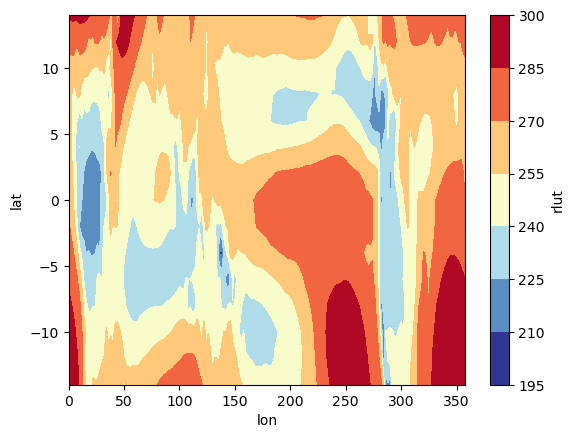

In [6]:
olr_data['cntl'].mean('time').plot.contourf(cmap='RdYlBu_r')

In [7]:
# 加载所有实验的降水数据
pr_data = load_all_precipitation_data()


加载所有降水数据

💾 内存状态 - 加载降水数据前
  进程物理内存使用: 1.29 GB
  进程虚拟内存使用: 19.77 GB
  进程内存占比: 0.3%
  系统可用内存: 267.27 GB / 501.87 GB


加载 CNTL...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_cntl_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((5000, 114), (15,), (180,))
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   估算数据大小: 0.10 GB

加载 P4K...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_p4k_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((5000, 114), (15,), (180,))
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   估算数据大小: 0.10 GB

加载 4CO2...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_4co2_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((5000, 114), (15,), (180,))
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   估算数据大小: 0.10 GB

✅ 成功加载 3 个实验的数据

💾 内存状态 - 加载降水数据后
  进程物理内

In [8]:
def preprocess_data_with_dask(data1, data2, ocean_mask):
    """
    使用 Dask 优化数据预处理流程
    
    Parameters:
    -----------
    pr_raw : xr.DataArray (with dask chunks)
        原始降水数据
    vdv_raw : xr.DataArray (with dask chunks)
        原始散度数据
    ocean_mask : xr.DataArray
        海洋掩膜
        
    Returns:
    --------
    pr_ano, vdv_ano : xr.DataArray
        预处理后的异常值数据（仍然是 dask 数组，延迟计算）
    """
    
    # 步骤1：计算异常值（去除年循环）- Dask 会自动优化这个 groupby 操作
    print("  📊 步骤1: 计算异常值（延迟计算）...")
    data1_ano = data1.groupby('time.dayofyear') - data1.groupby('time.dayofyear').mean()
    data2_ano = data2.groupby('time.dayofyear') - data2.groupby('time.dayofyear').mean()
    
    # 步骤2：应用海洋掩膜
    print("  🌊 步骤2: 应用海洋掩膜（延迟计算）...")
    ocean_mask_binary = ocean_mask.astype(float)
    data1_ano = data1_ano * ocean_mask_binary
    data2_ano = data2_ano * ocean_mask_binary
    
    # 步骤3：处理 NaN 和 Inf 值（延迟计算）
    print("  🧹 步骤3: 清理 NaN 和 Inf 值（延迟计算）...")
    
    # 使用 xr.where 处理 Inf（Dask 兼容）
    data1_ano = xr.where(np.isinf(data1_ano), np.nan, data1_ano)
    data2_ano = xr.where(np.isinf(data2_ano), np.nan, data2_ano)
    
    # 填充 NaN（Dask 兼容）
    data1_ano = data1_ano.fillna(0)
    data2_ano = data2_ano.fillna(0)
    
    # 再次去除年循环（使用 wave_tools 函数）
    print("  🔄 步骤4: 再次去除年循环（延迟计算）...")
    data1_ano = remove_annual_cycle(data1_ano)
    data2_ano = remove_annual_cycle(data2_ano)
    
    print(f"     data1_ano chunks: {data1_ano.chunks}")
    print(f"     data2_ano chunks: {data2_ano.chunks}")
    
    return data1_ano, data2_ano


print("✅ Dask 优化函数定义完成！")

✅ Dask 优化函数定义完成！


In [9]:


def calculate_cross_spectrum_dask(data_ano1, data_ano2, segLen=96, segOverLap=-65, symmetry='symm'):
    """ 使用 Dask 优化交叉谱计算流程    
    """
    # 由于交叉谱计算无法直接用 Dask 加速，这里我们先将数据计算出来
    print("  📊 计算交叉谱（Dask 版本）...")


    crossspectrum_results_dask = {}

    for exp_name in ['cntl', 'p4k', '4co2']:

        
        mem_monitor.print_memory_status(f"开始处理 {exp_name}")
        

        pr_raw = pr_data[exp_name].where(ocean_mask, drop=True)
        olr_raw = olr_data[exp_name].where(ocean_mask, drop=True)
        
        print(f"  📦 原始数据 chunks:")
        print(f"     pr_raw: {pr_raw.chunks if hasattr(pr_raw, 'chunks') else 'No chunks'}")
        print(f"     olr_raw: {olr_raw.chunks if hasattr(olr_raw, 'chunks') else 'No chunks'}")
        

        pr_ano, olr_ano = preprocess_data_with_dask(pr_raw, olr_raw, ocean_mask)


        pr_ano_computed, olr_ano_computed = dask.compute(pr_ano, olr_ano)
            

    
        mem_monitor.print_memory_status(f"预处理完成 {exp_name}")
        
        # ========== 计算交叉谱（这一步无法用 Dask 加速） ==========
        print(f"\n  📊 计算交叉谱...")
        
        
        result = calculate_cross_spectrum(
            pr_ano_computed, olr_ano_computed, 
            segLen=96, 
            segOverLap=-65,
            symmetry='symm',
            return_xarray=True
        )
        
        
        # 提取结果
        if result is None:
            print(f"    ✗ 交叉谱计算失败，返回None")
            continue
            
        stc_da = result['STC']
        zonalwnum = result['wave']
        freq = result['freq']
        
    
        crossspectrum_results_dask[exp_name] = {
            'STC': stc_da,
            'freq': freq,
            'wave': zonalwnum,
            'nseg': result['nseg'],
            'dof': result['dof'],
            'p': result['p'],
            'prob_coh2': result['prob_coh2']
        }
        
        
        mem_monitor.print_memory_status(f"完成 {exp_name}")
        
        # 清理内存
        del pr_ano, olr_ano, pr_ano_computed, olr_ano_computed
        gc.collect()
    return crossspectrum_results_dask

crossspectrum_results_dask = calculate_cross_spectrum_dask(
    pr_data, olr_data, 
    segLen=96, segOverLap=-65, symmetry='symm'
)

  📊 计算交叉谱（Dask 版本）...

💾 内存状态 - 开始处理 cntl
  进程物理内存使用: 1.30 GB
  进程虚拟内存使用: 19.77 GB
  进程内存占比: 0.3%
  系统可用内存: 267.25 GB / 501.87 GB

  📦 原始数据 chunks:
     pr_raw: ((5000, 114), (15,), (167,))
     olr_raw: ((5000, 114), (15,), (167,))
  📊 步骤1: 计算异常值（延迟计算）...
  🌊 步骤2: 应用海洋掩膜（延迟计算）...
  🧹 步骤3: 清理 NaN 和 Inf 值（延迟计算）...
  🔄 步骤4: 再次去除年循环（延迟计算）...
     data1_ano chunks: None
     data2_ano chunks: None

💾 内存状态 - 预处理完成 cntl
  进程物理内存使用: 2.18 GB
  进程虚拟内存使用: 23.14 GB
  进程内存占比: 0.4%
  系统可用内存: 265.77 GB / 501.87 GB


  📊 计算交叉谱...

💾 内存状态 - 完成 cntl
  进程物理内存使用: 2.19 GB
  进程虚拟内存使用: 23.14 GB
  进程内存占比: 0.4%
  系统可用内存: 263.53 GB / 501.87 GB


💾 内存状态 - 开始处理 p4k
  进程物理内存使用: 2.00 GB
  进程虚拟内存使用: 22.95 GB
  进程内存占比: 0.4%
  系统可用内存: 263.70 GB / 501.87 GB

  📦 原始数据 chunks:
     pr_raw: ((5000, 114), (15,), (167,))
     olr_raw: ((5000, 114), (15,), (167,))
  📊 步骤1: 计算异常值（延迟计算）...
  🌊 步骤2: 应用海洋掩膜（延迟计算）...
  🧹 步骤3: 清理 NaN 和 Inf 值（延迟计算）...
  🔄 步骤4: 再次去除年循环（延迟计算）...
     data1_ano chunks: None
     data2_ano chunks: Non

  CNTL: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 8016/8183
     有效的矢量数: 2016
  P4K: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 8016/8183
     有效的矢量数: 2016
  4CO2: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 8016/8183
     有效的矢量数: 2016

✅ 图片已保存: ../figures/pr&lhf_cross_spectrum/cross_spectrum_pr&olr_symm_99%.png


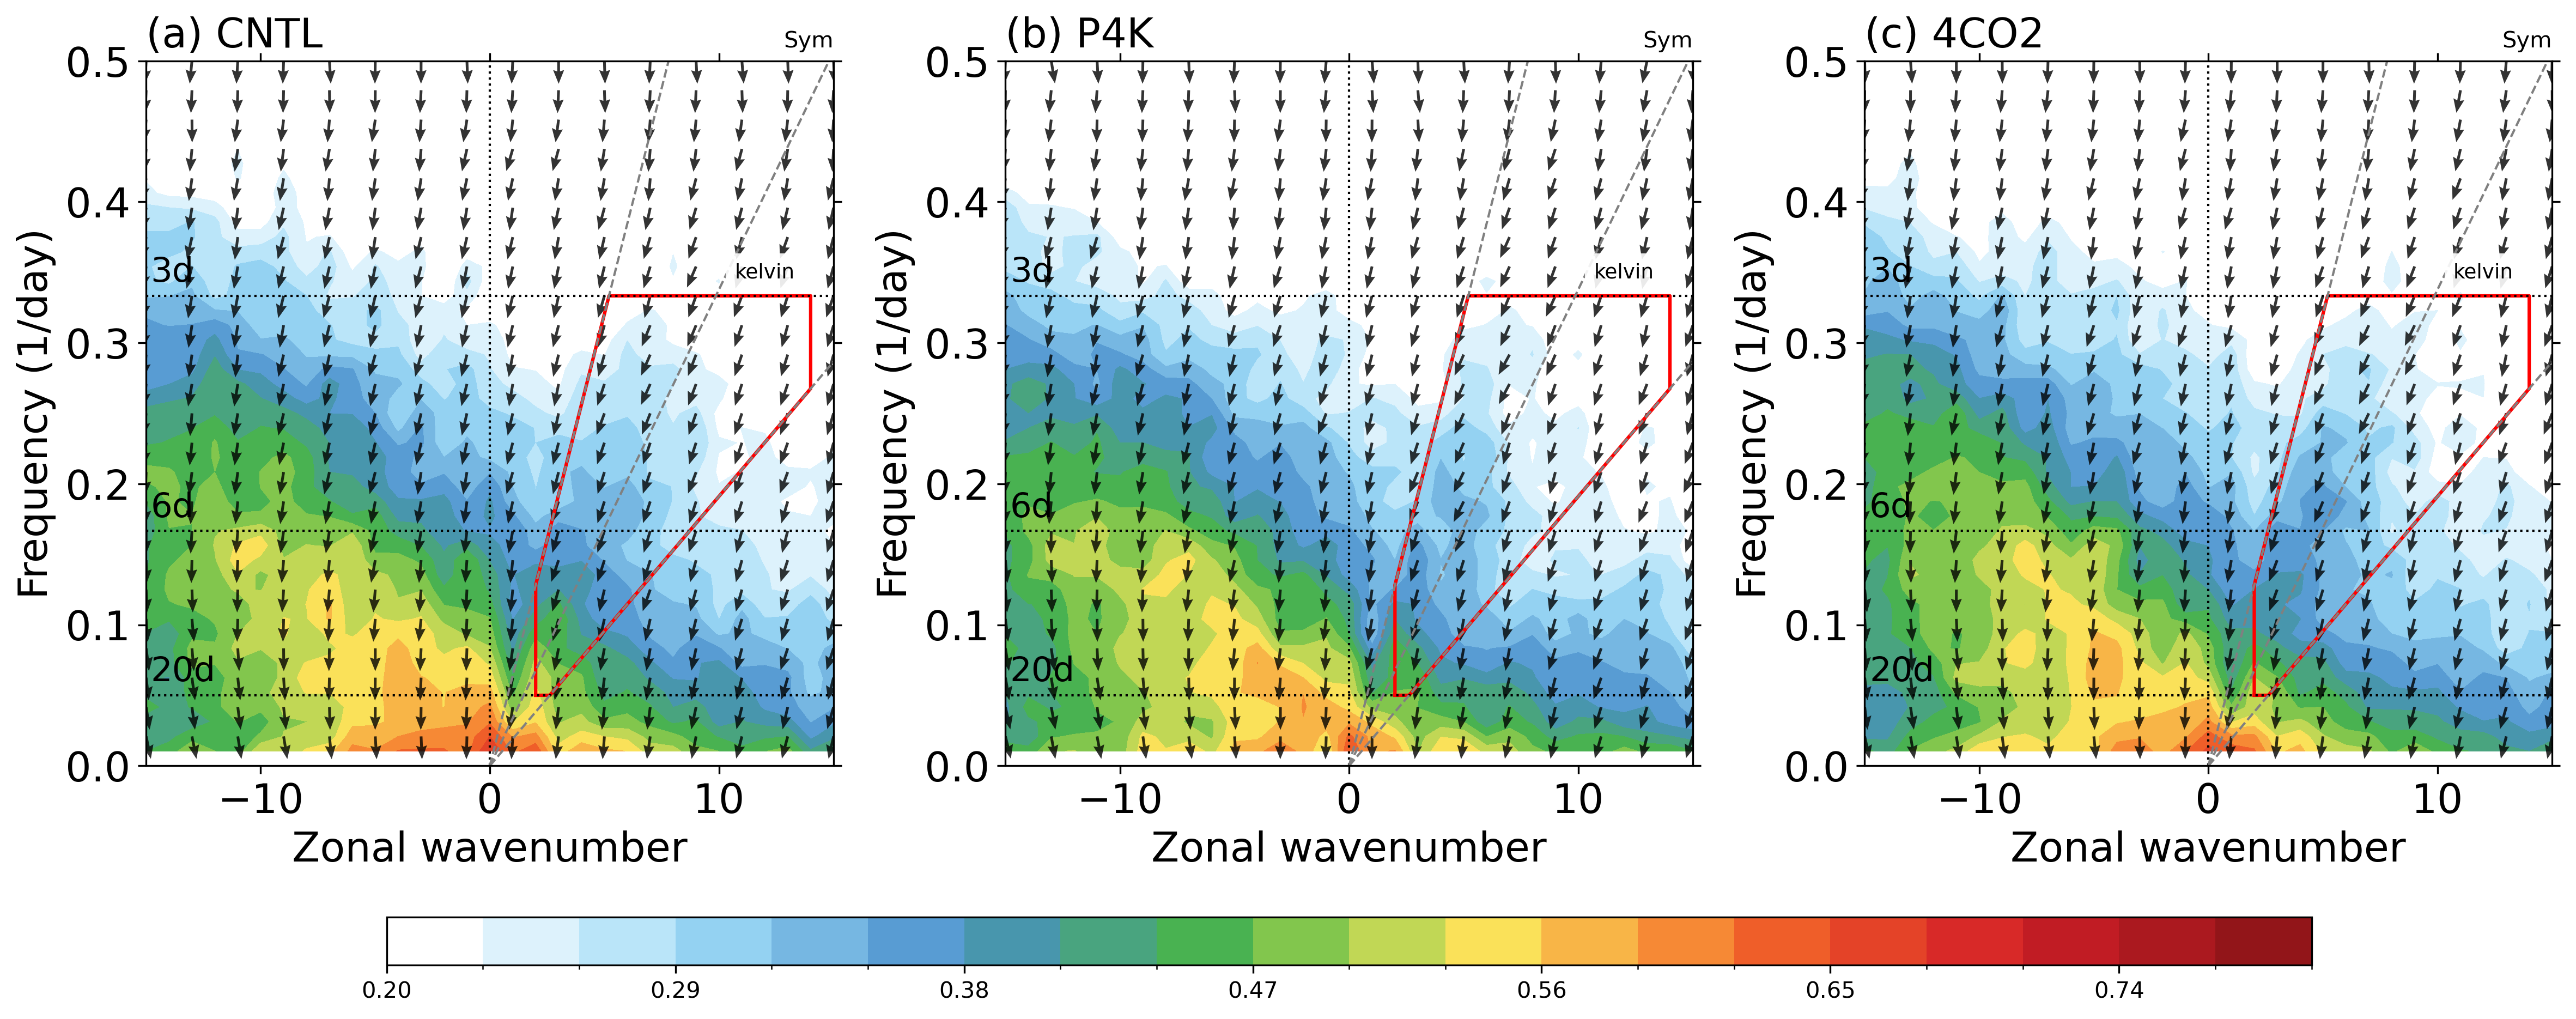

In [10]:
s2d = 86400
re = 6371 * 1000

# 创建3个子图
fig, axes = plt.subplots(1, 3, figsize=(16, 8), dpi=300)
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.15, wspace=0.25)
plt.rcParams.update({'font.size': 10})

exp_names = ['cntl', 'p4k', '4co2']
exp_titles = ['CNTL', 'P4K', '4CO2']

for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes)):
    plt.sca(ax)

    # 获取当前实验的结果
    stc = crossspectrum_results_dask[exp_name]['STC']
    zonalwnum = crossspectrum_results_dask[exp_name]['wave']
    freq = crossspectrum_results_dask[exp_name]['freq']
    
    # 🔑 关键：获取99%置信水平的临界值
    coh2_99_threshold_array = crossspectrum_results_dask[exp_name]['prob_coh2']
    
    # 如果是数组，取最大值（最保守的检验）
    if isinstance(coh2_99_threshold_array, np.ndarray) and coh2_99_threshold_array.size > 1:
        coh2_99_threshold = float(coh2_99_threshold_array.max())
    elif hasattr(coh2_99_threshold_array, 'item'):
        coh2_99_threshold = float(coh2_99_threshold_array.item())
    else:
        coh2_99_threshold = float(coh2_99_threshold_array)
    
    print(f"  {exp_name.upper()}: 99%显著性阈值 = {coh2_99_threshold:.6f}")
    
    # 获取coherence squared数据
    coh2_data = stc.sel(component='COH2')
    
    # 检查有多少点通过显著性检验
    n_significant = int((coh2_data >= coh2_99_threshold).sum())
    print(f"     通过99%显著性检验的点数: {n_significant}/{coh2_data.size}")
    
    # 🔑 使用99%置信水平阈值进行掩蔽
    coh2_data_masked = coh2_data.where(coh2_data >= coh2_99_threshold)

    # 绘制coherence squared的等高线图（只显示通过检验的）
    contourf = coh2_data_masked.plot.contourf(
        ax=ax,
        cmap=cmaps.WhiteBlueGreenYellowRed,
        levels=np.linspace(0.2, 0.8, 21),
        add_colorbar=False,
        add_labels=False,
        extend='neither'
    )

    # 准备矢量场数据
    skip = 2
    wave_sub = zonalwnum[::skip]
    freq_sub = freq[::skip]
    u_sub = stc.sel(component='V1').values[::skip, ::skip]
    v_sub = stc.sel(component='V2').values[::skip, ::skip]
    coh2_sub = stc.sel(component='COH2').values[::skip, ::skip]

    # 🔑 使用99%置信水平阈值掩蔽矢量场
    mask = coh2_sub < coh2_99_threshold
    u_masked = np.where(mask, np.nan, u_sub)
    v_masked = np.where(mask, np.nan, v_sub)
    
    # 检查有效矢量数
    n_valid_vectors = np.sum(~np.isnan(u_masked))
    print(f"     有效的矢量数: {n_valid_vectors}")

    # 添加矢量场
    if n_valid_vectors > 0:
        q = ax.quiver(
            wave_sub, freq_sub,
            u_masked, v_masked,
            scale=30, headwidth=4, headlength=5, 
            width=0.004, alpha=0.8
        )

    # 设置标题
    ax.set_title(f'({chr(97 + idx)}) {exp_title}', fontsize=18, loc='left')
    ax.set_title(f'Sym', fontsize=10, loc='right')

    # 设置坐标轴
    ax.set_ylabel('Frequency (1/day)', fontsize=18)
    ax.set_xlabel('Zonal wavenumber', fontsize=18)
    ax.set_xlim(-15, 15)
    ax.set_ylim(0, 0.5)
    kw_x, kw_y = get_curve()
    # 绘制CCKW波段
    ax.plot(kw_x[0], kw_y[0], 'red', linewidth=1.5, linestyle='solid', label='CCKW band')

    # 添加参考线
    d = np.array([3, 6, 20])
    dname = ['3d', '6d', '20d']
    he_all = np.array([8, 25, 90])
    cp = (9.8 * he_all) ** 0.5
    zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re

    # 零波数线
    ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')

    # 周期线
    for dd in range(len(d)):
        ax.plot([-15, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
        ax.text(-14.8, 1/d[dd] + 0.01, dname[dd], fontsize=15, color='k')

    # Kelvin波色散关系
    for hh in range(len(he_all)):
        ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')

    # 添加"kelvin"标签
    ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
            bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})
    ax.tick_params(labelsize=18, which='both', top=True, right=True)

# 添加颜色条
cbar = fig.colorbar(contourf, ax=axes, orientation='horizontal', 
                    pad=0.15, aspect=40, shrink=0.8)

fig.savefig(FIG_SAVE_DIR + 'cross_spectrum_pr&olr_symm_99%.png', bbox_inches='tight')
print(f"\n✅ 图片已保存: {FIG_SAVE_DIR}cross_spectrum_pr&olr_symm_99%.png")